Célula — Coleta




In [8]:
import requests
import pandas as pd

BASE_URL = "https://olinda.bcb.gov.br/olinda/servico/Pix_DadosAbertos/versao/v1/odata"

def get_pix_data(recurso, ano_mes, extra_filter=None, top=None):
    url = f"{BASE_URL}/{recurso}(Database=@Database)?$format=json&@Database='{ano_mes}'"
    url += f"&$filter=AnoMes eq {ano_mes}"

    if extra_filter:
        url += f" and {extra_filter}"
    if top:
        url += f"&$top={top}"

    response = requests.get(url)
    response.raise_for_status()
    data = response.json()

    return pd.DataFrame(data.get("value", []))

Célula — Teste rápido: estatísticas gerais de transações

In [9]:
df_teste = get_pix_data("EstatisticasTransacoesPix", "202506")
print(df_teste.shape)
df_teste.head()

(11662, 12)


,AnoMes,PAG_PFPJ,REC_PFPJ,PAG_REGIAO,REC_REGIAO,PAG_IDADE,REC_IDADE,FORMAINICIACAO,NATUREZA,FINALIDADE,VALOR,QUANTIDADE
0,202506,PF,PF,Nao informado,NORDESTE,entre 50 e 59 anos,entre 50 e 59 anos,DICT,P2P,Pix,1.686679e+06,2972
1,202506,PF,PF,Nao informado,Nao informado,até 19 anos,entre 40 e 49 anos,DICT,P2P,Pix,1.410601e+05,687
2,202506,PF,PJ,SUL,SUL,entre 20 e 29 anos,Nao se aplica,DICT,P2B,Pix,2.026022e+09,5433566
3,202506,PF,PF,NORDESTE,SUL,entre 20 e 29 anos,entre 30 e 39 anos,QRES,P2P,Pix,1.576426e+06,38585
4,202506,PF,PF,NORDESTE,NORDESTE,entre 40 e 49 anos,Nao informado,DICT,P2P,Pix,1.537150e+04,207


Célula — Coleta da série histórica completa

In [7]:
import time

meses = pd.date_range("2020-11", "2026-06", freq="MS").strftime("%Y%m")

dfs = []
falhas = []

for m in meses:
    try:
        df_m = get_pix_data("EstatisticasTransacoesPix", m)
        dfs.append(df_m)
        print(f"{m}: {len(df_m)} linhas")
    except requests.HTTPError as e:
        print(f"Falhou em {m}: {e}")
        falhas.append(m)
    time.sleep(0.3)

df_pix = pd.concat(dfs, ignore_index=True)
print(f"\nTotal: {df_pix.shape[0]} linhas, {df_pix.shape[1]} colunas")
print(f"Meses com falha: {falhas}")

202011: 1788 linhas
202012: 1959 linhas
202101: 2043 linhas
202102: 2897 linhas
202103: 2096 linhas
202104: 2121 linhas
202105: 2157 linhas
202106: 8270 linhas
202107: 9771 linhas
202108: 8775 linhas
202109: 8752 linhas
202110: 8903 linhas
202111: 8980 linhas
202112: 9265 linhas
202201: 9342 linhas
202202: 9497 linhas
202203: 9687 linhas
202204: 9723 linhas
202205: 9935 linhas
202206: 10048 linhas
202207: 10146 linhas
202208: 10254 linhas
202209: 10375 linhas
202210: 10517 linhas
202211: 10502 linhas
202212: 10670 linhas
202301: 10634 linhas
202302: 10631 linhas
202303: 10756 linhas
202304: 10831 linhas
202305: 10897 linhas
202306: 10891 linhas
202307: 11027 linhas
202308: 11067 linhas
202309: 10934 linhas
202310: 11058 linhas
202311: 11126 linhas
202312: 11182 linhas
202401: 11143 linhas
202402: 11179 linhas
202403: 11250 linhas
202404: 11148 linhas
202405: 11179 linhas
202406: 11409 linhas
202407: 11596 linhas
202408: 11434 linhas
202409: 11394 linhas
202410: 11406 linhas
202411: 114

Célula — Salvar e agregar

In [10]:
df_pix.to_csv("pix_transacoes_completo.csv", index=False)

In [11]:
serie_mensal = df_pix.groupby("AnoMes")[["VALOR", "QUANTIDADE"]].sum().reset_index()
serie_mensal["data"] = pd.to_datetime(serie_mensal["AnoMes"], format="%Y%m")

In [12]:
df_pix.to_csv("pix_transacoes_completo.csv", index=False)

serie_mensal = df_pix.groupby("AnoMes")[["VALOR", "QUANTIDADE"]].sum().reset_index()
serie_mensal["data"] = pd.to_datetime(serie_mensal["AnoMes"], format="%Y%m")
serie_mensal = serie_mensal.sort_values("data")
serie_mensal

,AnoMes,VALOR,QUANTIDADE,data
0,202011,2.586985e+10,29524895,2020-11-01
1,202012,1.072007e+11,124890953,2020-12-01
2,202101,1.379196e+11,169766107,2021-01-01
3,202102,1.696052e+11,229417959,2021-02-01
4,202103,2.383408e+11,328459612,2021-03-01
...,...,...,...,...
63,202602,2.563439e+12,5986274045,2026-02-01
64,202603,3.012738e+12,6741996455,2026-03-01
65,202604,2.896675e+12,6680896774,2026-04-01
66,202605,2.957488e+12,7121879045,2026-05-01


Célula — evolução do volume financeiro

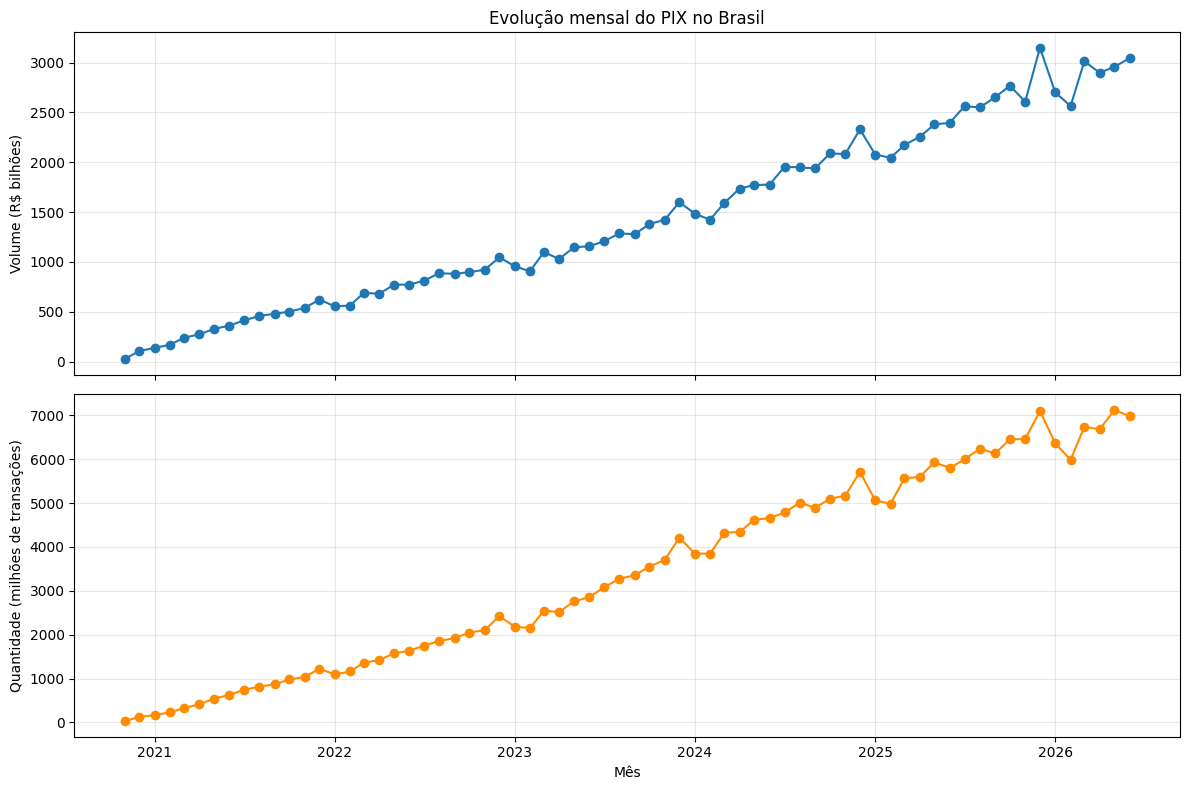

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(serie_mensal["data"], serie_mensal["VALOR"] / 1e9, marker="o", linewidth=1.5)
axes[0].set_ylabel("Volume (R$ bilhões)")
axes[0].set_title("Evolução mensal do PIX no Brasil")
axes[0].grid(alpha=0.3)

axes[1].plot(serie_mensal["data"], serie_mensal["QUANTIDADE"] / 1e6, marker="o", color="darkorange", linewidth=1.5)
axes[1].set_ylabel("Quantidade (milhões de transações)")
axes[1].set_xlabel("Mês")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

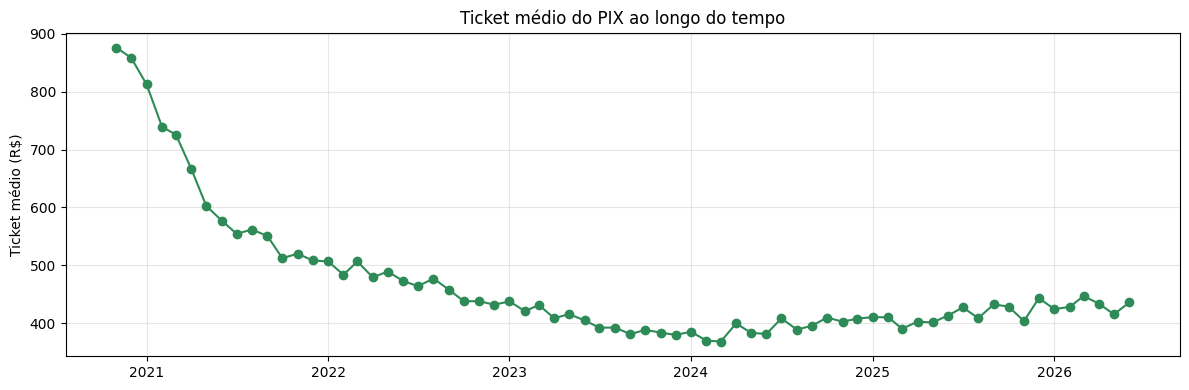

In [14]:
serie_mensal["ticket_medio"] = serie_mensal["VALOR"] / serie_mensal["QUANTIDADE"]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(serie_mensal["data"], serie_mensal["ticket_medio"], marker="o", color="seagreen")
ax.set_ylabel("Ticket médio (R$)")
ax.set_title("Ticket médio do PIX ao longo do tempo")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

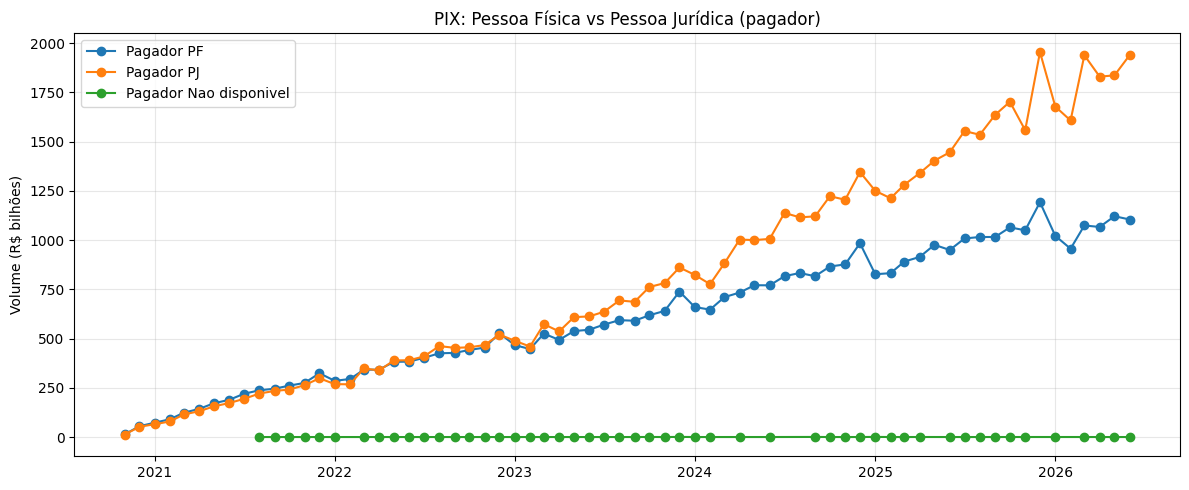

In [15]:
pf_pj = df_pix.groupby(["AnoMes", "PAG_PFPJ"])[["VALOR", "QUANTIDADE"]].sum().reset_index()
pf_pj["data"] = pd.to_datetime(pf_pj["AnoMes"], format="%Y%m")

fig, ax = plt.subplots(figsize=(12, 5))
for tipo in pf_pj["PAG_PFPJ"].unique():
    sub = pf_pj[pf_pj["PAG_PFPJ"] == tipo]
    ax.plot(sub["data"], sub["VALOR"] / 1e9, marker="o", label=f"Pagador {tipo}")
ax.set_ylabel("Volume (R$ bilhões)")
ax.set_title("PIX: Pessoa Física vs Pessoa Jurídica (pagador)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

calcular o ticket médio separado por PF e PJ

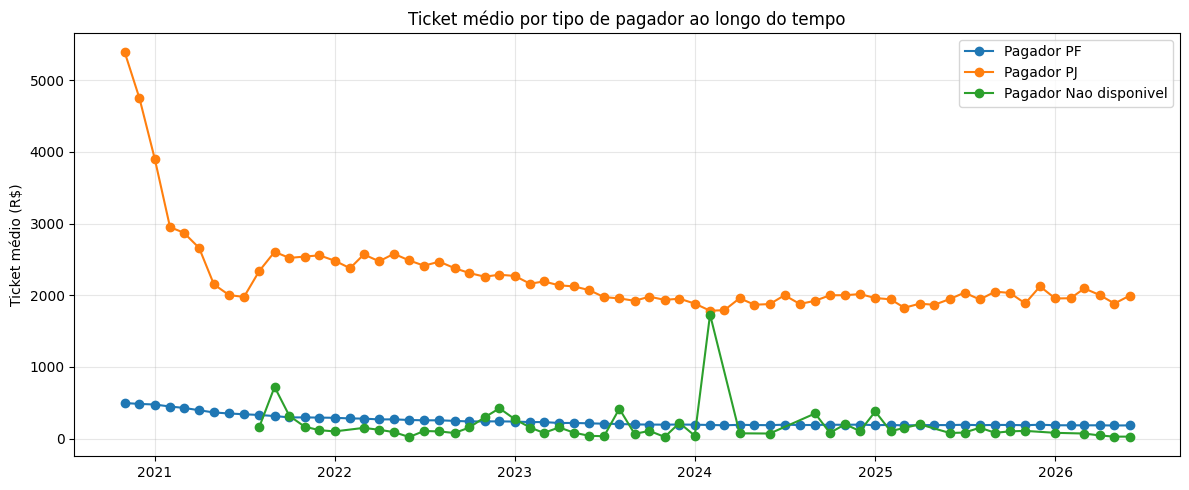

In [16]:
pf_pj_ticket = df_pix.groupby(["AnoMes", "PAG_PFPJ"])[["VALOR", "QUANTIDADE"]].sum().reset_index()
pf_pj_ticket["ticket_medio"] = pf_pj_ticket["VALOR"] / pf_pj_ticket["QUANTIDADE"]
pf_pj_ticket["data"] = pd.to_datetime(pf_pj_ticket["AnoMes"], format="%Y%m")

fig, ax = plt.subplots(figsize=(12, 5))
for tipo in pf_pj_ticket["PAG_PFPJ"].unique():
    sub = pf_pj_ticket[pf_pj_ticket["PAG_PFPJ"] == tipo]
    ax.plot(sub["data"], sub["ticket_medio"], marker="o", label=f"Pagador {tipo}")
ax.set_ylabel("Ticket médio (R$)")
ax.set_title("Ticket médio por tipo de pagador ao longo do tempo")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
dfs_fraude = []
for m in meses:
    try:
        df_m = get_pix_data("EstatisticasFraudesPix", m)
        dfs_fraude.append(df_m)
    except requests.HTTPError as e:
        print(f"Falhou em {m}: {e}")
    time.sleep(0.3)

df_fraude = pd.concat(dfs_fraude, ignore_index=True)
df_fraude.to_csv("pix_fraude_completo.csv", index=False)
df_fraude.head()

,AnoMes,QtdePixcontestados,Qtdecontestacoesaceitas,Qtdecontestacoesrejeitadas,Qtdecontestacoesaceitasacada100mil,QtdeUsuarioscommarcacoesdefraude,QtdeChavesPixcommarcacoesdefraude,ValorPixcontestadosaceitos,QuantidadedevolvidaintegralmentepormeiodoMED,ValorPixdevolvidosintegralmente,...,ValorPixnaodevolvidossaldoinsuficiente,Quantidadedenaodevolvidoscontaencerrada,Valornaodevolvidoscontaencerrada,Quantidadedenaodevolvidosmotivosdiversos,ValorPixnaodevolvidosmotivosdiversos,PercentualdeDevolucao,QtdePixbloqueadoscautelarmenteeliberados,ValorPixbloqueadoscautelarmenteeliberados,QtdePixbloqueadoscautelarmenteedevolvidos,ValorPixbloqueadoscautelarmenteedevolvidos
0,202201,71508,57777,13731,5.284,22515,24819,1.225589e+08,5673,4261762.10,...,6.207817e+07,5074,15573593.85,3955,7775308.77,5.29,35045,24780856.85,20904,10049037.94
1,202202,78638,60682,17956,5.220,23998,25898,1.360368e+08,5301,5355273.06,...,6.418456e+07,6190,17471344.77,3401,9718283.44,5.99,35082,29383993.38,19507,11319480.00
2,202203,134964,105016,29948,7.708,35612,39096,2.169399e+08,11074,10998092.06,...,1.027211e+08,13035,22737501.12,8147,21079506.77,7.84,28239,17914248.63,23376,10421977.05
3,202204,152636,114763,37873,8.082,32366,35562,1.781637e+08,11816,8494563.65,...,8.068369e+07,24293,31755819.62,9855,18095234.98,6.78,26460,22823420.10,15415,12057882.31
4,202205,229402,149006,80396,9.460,35465,39313,2.248629e+08,12682,8179939.00,...,9.549533e+07,43379,47191483.62,11374,21817129.61,5.49,27002,29038731.29,15715,13576390.05


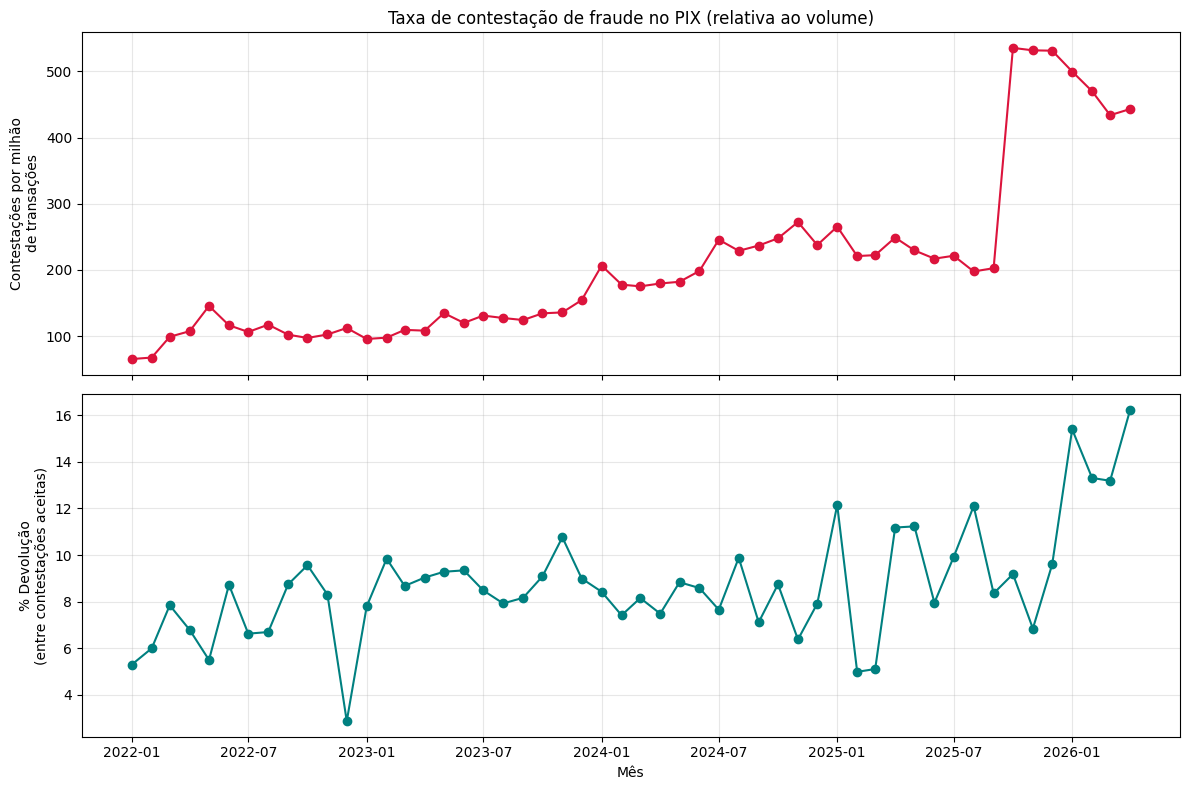

In [21]:
comparativo = serie_mensal.merge(
    df_fraude.drop(columns=["data"]),
    on="AnoMes",
    suffixes=("_total", "_fraude")
)

comparativo["contestacoes_por_milhao"] = (
    comparativo["QtdePixcontestados"] / comparativo["QUANTIDADE"] * 1_000_000
)

comparativo["pct_valor_fraude"] = (
    comparativo["ValorPixcontestadosaceitos"] / comparativo["VALOR"] * 100
)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(comparativo["data"], comparativo["contestacoes_por_milhao"], marker="o", color="crimson")
axes[0].set_ylabel("Contestações por milhão\nde transações")
axes[0].set_title("Taxa de contestação de fraude no PIX (relativa ao volume)")
axes[0].grid(alpha=0.3)

axes[1].plot(comparativo["data"], comparativo["PercentualdeDevolucao"], marker="o", color="teal")
axes[1].set_ylabel("% Devolução\n(entre contestações aceitas)")
axes[1].set_xlabel("Mês")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Célula — Teste com um mês

In [25]:
def get_pix_data_municipio(ano_mes, top=None):
    url = f"{BASE_URL}/TransacoesPixPorMunicipio(DataBase=@DataBase)?$format=json&@DataBase='{ano_mes}'"
    url += f"&$filter=AnoMes eq {ano_mes}"

    if top:
        url += f"&$top={top}"

    response = requests.get(url)
    response.raise_for_status()
    data = response.json()

    return pd.DataFrame(data.get("value", []))

df_geo_teste = get_pix_data_municipio("202506")
print(df_geo_teste.shape)
df_geo_teste.head()

(5571, 19)


,AnoMes,Municipio_Ibge,Municipio,Estado_Ibge,Estado,Sigla_Regiao,Regiao,VL_PagadorPF,QT_PagadorPF,VL_PagadorPJ,QT_PagadorPJ,VL_RecebedorPF,QT_RecebedorPF,VL_RecebedorPJ,QT_RecebedorPJ,QT_PES_PagadorPF,QT_PES_PagadorPJ,QT_PES_RecebedorPF,QT_PES_RecebedorPJ
0,202506,3201803.0,DIVINO DE SÃO LOURENÇO,32.0,ESPÍRITO SANTO,SE,SUDESTE,12938270.78,76860,7978732.45,4774,14692104.78,37696,4536454.11,16036,2479,202,2468,193
1,202506,3137502.0,LAGOA FORMOSA,31.0,MINAS GERAIS,SE,SUDESTE,99821610.59,265102,32243019.96,16274,97205418.00,154989,35506517.56,59075,9665,724,9271,697
2,202506,2600401.0,ÁGUA PRETA,26.0,PERNAMBUCO,NE,NORDESTE,65754210.52,562292,5826164.89,8019,61139502.21,358113,5919911.26,40030,14852,257,14830,227
3,202506,4310900.0,JACUTINGA,43.0,RIO GRANDE DO SUL,SU,SUL,8351188.05,32435,5245090.58,1919,8698221.55,15170,3858170.88,6135,1778,168,1575,175
4,202506,5005152.0,JUTI,50.0,MATO GROSSO DO SUL,CO,CENTRO-OESTE,22245297.32,140708,6653791.93,8908,21572232.43,68976,5980820.81,25816,3974,268,3841,252


Célula — Coleta de 3 momentos (início, meio, atual)

In [26]:
meses_geo = ["202101", "202401", "202606"]  # início, meio do caminho, mais recente

dfs_geo = []
for m in meses_geo:
    df_m = get_pix_data_municipio(m)
    dfs_geo.append(df_m)
    print(f"{m}: {len(df_m)} municípios")

df_geo = pd.concat(dfs_geo, ignore_index=True)
df_geo.to_csv("pix_municipios_snapshots.csv", index=False)

202101: 5569 municípios
202401: 5569 municípios
202606: 5572 municípios


Célula — Agregado por região (visão macro)

In [27]:
df_geo["VL_TOTAL"] = df_geo["VL_PagadorPF"] + df_geo["VL_PagadorPJ"]
df_geo["QT_TOTAL"] = df_geo["QT_PagadorPF"] + df_geo["QT_PagadorPJ"]

regiao_ano = df_geo.groupby(["AnoMes", "Regiao"])[["VL_TOTAL", "QT_TOTAL"]].sum().reset_index()

pivot_regiao = regiao_ano.pivot(index="Regiao", columns="AnoMes", values="VL_TOTAL")
pivot_regiao

AnoMes,202101,202401,202606
Regiao,,,
CENTRO-OESTE,1.475240e+10,1.337827e+11,2.765799e+11
NORDESTE,2.113953e+10,2.355089e+11,4.329324e+11
NORTE,7.135203e+09,8.331002e+10,1.608644e+11
Nao informado,8.394529e+07,7.853066e+08,7.470676e+09
SUDESTE,6.947633e+10,7.773349e+11,1.679844e+12
SUL,2.533215e+10,2.524857e+11,4.864022e+11


In [28]:
pivot_pct = pivot_regiao.div(pivot_regiao.sum(axis=0), axis=1) * 100
pivot_pct.round(2)

AnoMes,202101,202401,202606
Regiao,,,
CENTRO-OESTE,10.70,9.02,9.09
NORDESTE,15.33,15.88,14.22
NORTE,5.17,5.62,5.28
Nao informado,0.06,0.05,0.25
SUDESTE,50.37,52.41,55.18
SUL,18.37,17.02,15.98


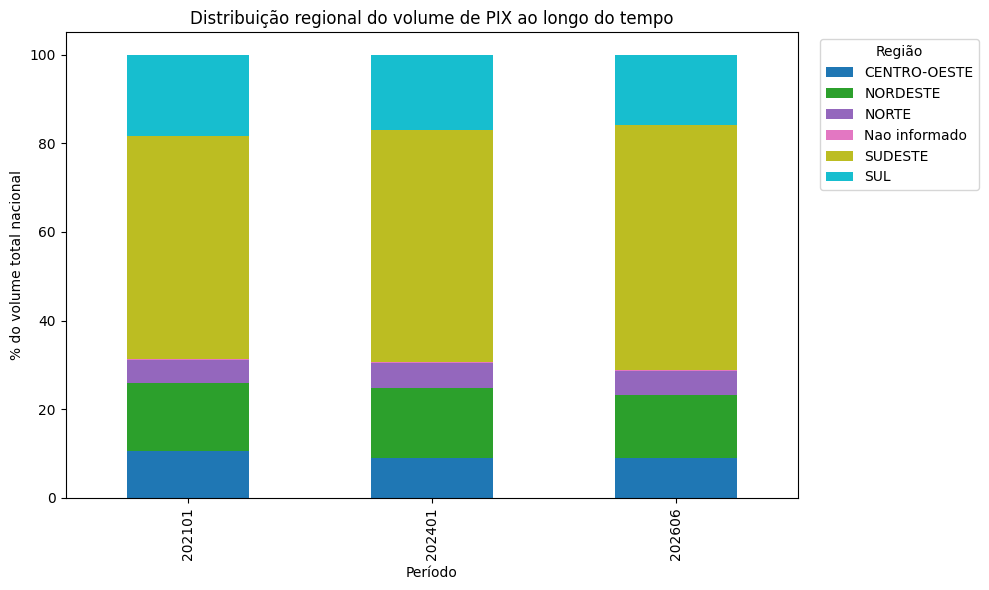

In [29]:
fig, ax = plt.subplots(figsize=(10, 6))
pivot_pct.T.plot(kind="bar", stacked=True, ax=ax, colormap="tab10")
ax.set_ylabel("% do volume total nacional")
ax.set_xlabel("Período")
ax.set_title("Distribuição regional do volume de PIX ao longo do tempo")
ax.legend(title="Região", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [31]:
pivot_qt = df_geo.groupby(["AnoMes", "Regiao"])["QT_TOTAL"].sum().unstack(level=0)
pivot_qt_pct = pivot_qt.div(pivot_qt.sum(axis=0), axis=1) * 100
pivot_qt_pct.round(2)

AnoMes,202101,202401,202606
Regiao,,,
CENTRO-OESTE,10.80,8.32,8.86
NORDESTE,19.87,27.13,26.72
NORTE,6.97,9.49,9.96
Nao informado,0.05,0.04,0.07
SUDESTE,49.31,42.54,42.32
SUL,13.01,12.48,12.07


Mapa por estado

In [32]:
import plotly.express as px

# agrega por estado, usando o snapshot mais recente
df_2026 = df_geo[df_geo["AnoMes"] == 202606].copy()

estado_agg = df_2026.groupby(["Estado", "Sigla_Regiao"]).agg(
    VL_TOTAL=("VL_TOTAL", "sum"),
    QT_TOTAL=("QT_TOTAL", "sum")
).reset_index()

# sigla de 2 letras do estado (necessária pro geojson) -- mapeamento manual
sigla_uf = {
    "ACRE": "AC", "ALAGOAS": "AL", "AMAPÁ": "AP", "AMAZONAS": "AM", "BAHIA": "BA",
    "CEARÁ": "CE", "DISTRITO FEDERAL": "DF", "ESPÍRITO SANTO": "ES", "GOIÁS": "GO",
    "MARANHÃO": "MA", "MATO GROSSO": "MT", "MATO GROSSO DO SUL": "MS", "MINAS GERAIS": "MG",
    "PARÁ": "PA", "PARAÍBA": "PB", "PARANÁ": "PR", "PERNAMBUCO": "PE", "PIAUÍ": "PI",
    "RIO DE JANEIRO": "RJ", "RIO GRANDE DO NORTE": "RN", "RIO GRANDE DO SUL": "RS",
    "RONDÔNIA": "RO", "RORAIMA": "RR", "SANTA CATARINA": "SC", "SÃO PAULO": "SP",
    "SERGIPE": "SE", "TOCANTINS": "TO"
}
estado_agg["UF"] = estado_agg["Estado"].str.upper().map(sigla_uf)
estado_agg["VL_bilhoes"] = estado_agg["VL_TOTAL"] / 1e9

geojson_url = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson"

fig = px.choropleth(
    estado_agg,
    geojson=geojson_url,
    locations="UF",
    featureidkey="properties.sigla",
    color="VL_bilhoes",
    color_continuous_scale="YlOrRd",
    scope="south america",
    labels={"VL_bilhoes": "Volume PIX (R$ bi)"},
    title="Volume de PIX por estado — Junho/2026"
)
fig.update_geos(fitbounds="locations", visible=False)
fig.update_layout(margin={"r":0,"t":40,"l":0,"b":0})
fig.show()